# Inventory Analytics - Exploratory Data Analysis

## Business Background
This dataset simulates the inventory operations of a retail company.

The objective of this analysis is to evaluate inventory performance, supplier efficiency, demand forecasting accuracy, and regional sales performance.
The insights generated from this notebook will support inventory optimization and business decision-making.

Business Questions
1. Which products generate the highest sales?
2. Which warehouses face inventory shortages?
3. Are reorder points appropriately configured?
4. Which suppliers have long lead times?
5. How accurate are demand forecasts?
6. Which regions perform best?
7. What business actions can improve inventory performance?

## Dataset Overview

In [1]:
import pandas as pd
feature_df = pd.read_csv(
    "../data/processed/inventory_clean.csv"
)
feature_df.head()

,date,sku_id,warehouse_id,supplier_id,region,units_sold,inventory_level,supplier_lead_time_days,reorder_point,order_quantity,...,day,quarter,lead_time_category,lead_time_demand,projected_inventory_after_lead_time,lead_time_reorder_risk,projected_stockout_risk,forecast_error,absolute_forecast_error,forecast_direction
0,2024-01-01,sku_1,wh_1,sup_8,west,10,592,14,379,0,...,1,1,slow,119.28,472.72,False,False,-1.48,1.48,underforecast
1,2024-01-02,sku_1,wh_1,sup_8,west,17,575,14,379,0,...,2,1,slow,260.82,314.18,True,False,1.63,1.63,overforecast
2,2024-01-03,sku_1,wh_1,sup_8,north,35,540,14,379,0,...,3,1,slow,554.68,-14.68,True,True,4.62,4.62,overforecast
3,2024-01-04,sku_1,wh_1,sup_8,south,24,516,14,379,0,...,4,1,slow,272.02,243.98,True,False,-4.57,4.57,underforecast
4,2024-01-05,sku_1,wh_1,sup_8,west,21,495,14,379,0,...,5,1,slow,261.80,233.20,True,False,-2.30,2.30,underforecast


In [2]:
display(feature_df.info())
display(feature_df.shape)
display(feature_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   date                                 91250 non-null  str    
 1   sku_id                               91250 non-null  str    
 2   warehouse_id                         91250 non-null  str    
 3   supplier_id                          91250 non-null  str    
 4   region                               91250 non-null  str    
 5   units_sold                           91250 non-null  int64  
 6   inventory_level                      91250 non-null  int64  
 7   supplier_lead_time_days              91250 non-null  int64  
 8   reorder_point                        91250 non-null  int64  
 9   order_quantity                       91250 non-null  int64  
 10  unit_cost                            91250 non-null  float64
 11  unit_price                           91

None

(91250, 37)

,units_sold,inventory_level,supplier_lead_time_days,reorder_point,order_quantity,unit_cost,unit_price,promotion_flag,stockout_flag,demand_forecast,...,inventory_gap,days_of_supply,year,month,day,quarter,lead_time_demand,projected_inventory_after_lead_time,forecast_error,absolute_forecast_error
count,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.0,91250.000000,...,91250.000000,90358.000000,91250.0,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000
mean,20.051156,471.522312,7.984000,300.068000,19.272493,12.203320,18.261800,0.101589,0.0,20.082033,...,171.454312,45.134360,2024.0,6.498630,15.715068,2.501370,160.359884,311.162428,0.030877,2.381533
std,9.057199,133.488002,3.907929,54.879945,82.340831,4.574982,7.121136,0.302109,0.0,9.503955,...,122.626009,477.181086,0.0,3.443993,8.787394,1.116813,115.436038,179.120087,2.990064,1.808225
min,0.000000,168.000000,2.000000,201.000000,0.000000,5.020000,6.950000,0.000000,0.0,0.000000,...,-49.000000,3.719599,2024.0,1.000000,1.000000,1.000000,0.000000,-541.660000,-13.000000,0.000000
25%,13.000000,370.000000,4.000000,252.000000,0.000000,8.180000,12.000000,0.000000,0.0,12.950000,...,71.000000,16.118469,2024.0,4.000000,8.000000,2.000000,67.800000,193.617500,-1.990000,0.950000
50%,20.000000,461.000000,8.000000,300.000000,0.000000,11.990000,18.180000,0.000000,0.0,19.950000,...,160.000000,23.486595,2024.0,7.000000,16.000000,3.000000,133.420000,313.600000,0.010000,2.000000
75%,27.000000,564.000000,11.000000,346.000000,0.000000,16.320000,23.390000,0.000000,0.0,26.930000,...,258.000000,37.021476,2024.0,9.000000,23.000000,3.000000,230.355000,434.677500,2.030000,3.440000
max,48.000000,990.000000,14.000000,398.000000,499.000000,19.760000,35.100000,1.000000,0.0,61.420000,...,744.000000,74900.000000,2024.0,12.000000,31.000000,4.000000,835.380000,957.840000,14.080000,14.080000


The processed dataset contains cleaned records and engineered features for downstream business analysis.

## Sales Performance Analysis

In [3]:
sales_by_sku = (
    feature_df
    .groupby("sku_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_sku.head(10)

sku_id
sku_18    37225
sku_1     37018
sku_33    37000
sku_47    36910
sku_13    36904
sku_9     36855
sku_4     36809
sku_12    36785
sku_3     36776
sku_31    36742
Name: units_sold, dtype: int64

(36000.0, 37500.0)

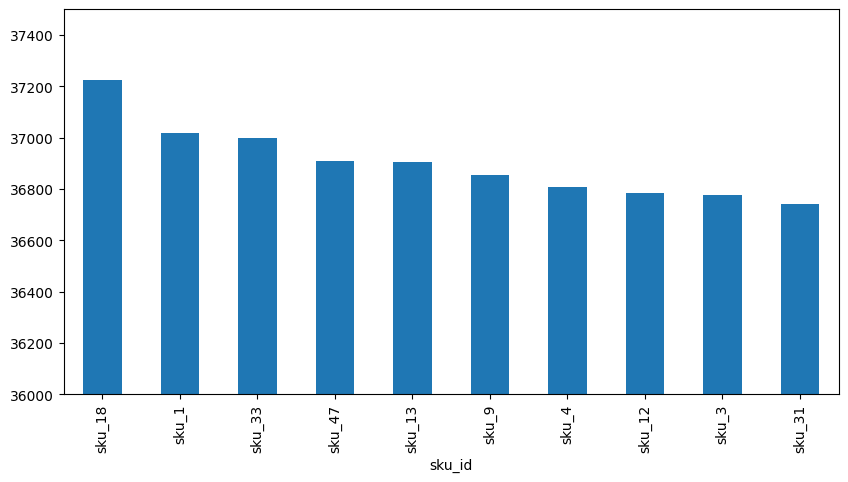

In [4]:
ax= sales_by_sku.head(10).plot.bar(figsize=(10, 5))
ax.set_ylim(36000, 37500)

In [5]:
# Average Sales
feature_df["units_sold"].describe()

count    91250.000000
mean        20.051156
std          9.057199
min          0.000000
25%         13.000000
50%         20.000000
75%         27.000000
max         48.000000
Name: units_sold, dtype: float64

In [6]:
# Warehouse Sales
feature_df.groupby("warehouse_id")["units_sold"].sum()

warehouse_id
wh_1    366843
wh_2    366004
wh_3    366051
wh_4    365705
wh_5    365065
Name: units_sold, dtype: int64

In [7]:
# Region Sales
feature_df.groupby("region")["units_sold"].sum()

region
east     459869
north    459774
south    456883
west     453142
Name: units_sold, dtype: int64

### Business Insight

SKU_18 contributes the highest sales volume.

east region generates the largest sales.

Warehouse WH_1 processes the highest sales volume.

## Inventory Analysis

<Axes: >

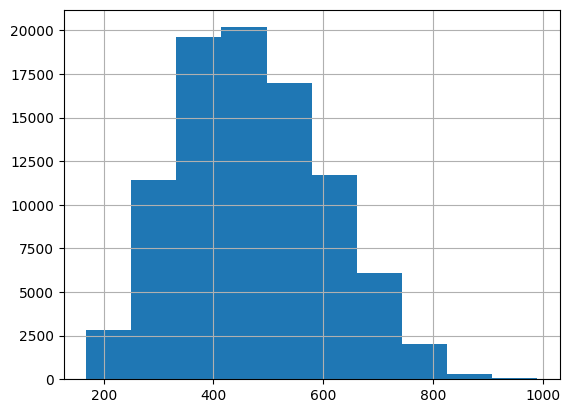

In [8]:
# Inventory Distribution
feature_df["inventory_level"].hist()

In [9]:
# Inventory vs Reorder Point
feature_df["inventory_shortage"] = (
    feature_df["inventory_level"]
    <
    feature_df["reorder_point"]
)
feature_df["inventory_shortage"].value_counts()

inventory_shortage
False    86463
True      4787
Name: count, dtype: int64

In [10]:
# Warehouse
feature_df.groupby("warehouse_id")[
    "inventory_shortage"
].mean()

warehouse_id
wh_1    0.052384
wh_2    0.052274
wh_3    0.052822
wh_4    0.051836
wh_5    0.052986
Name: inventory_shortage, dtype: float64

Warehouse WH_1 experiences the highest inventory shortage rate.

## Supplier Analysis

In [11]:
# Lead Time
feature_df.groupby("supplier_id")[
    "supplier_lead_time_days"
].mean().sort_values(ascending=True)

supplier_id
sup_5     6.956522
sup_10    7.407407
sup_7     7.558824
sup_6     7.900000
sup_1     8.107143
sup_9     8.187500
sup_3     8.260870
sup_2     8.423077
sup_8     8.500000
sup_4     8.640000
Name: supplier_lead_time_days, dtype: float64

Supplier SUP_5 consistently delivers with shorter lead times.

## Forecast Analysis

<Axes: >

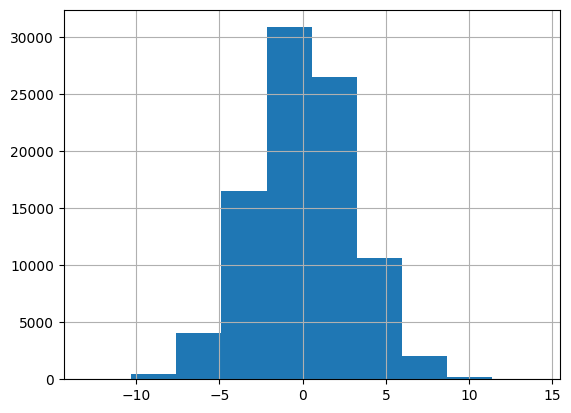

In [12]:
#Forecast Error
feature_df["forecast_error"].hist()

In [ ]:
feature_df.groupby("region")[
    "forecast_accuracy"
].mean().sort_values(ascending=False)

region
east     0.766968
west     0.759436
north    0.753817
south    0.742454
Name: forecast_accuracy, dtype: float64

Forecast accuracy is significantly lower in the South region.

## Regional Analysis

In [ ]:
# Region KPI
feature_df.groupby("region").agg({
    "units_sold":"sum",
    "inventory_level":"mean",
    "forecast_accuracy":"mean"
})

,units_sold,inventory_level,forecast_accuracy
region,,,
east,459869,473.046743,0.766968
north,459774,470.785235,0.753817
south,456883,472.159507,0.742454
west,453142,470.085448,0.759436


## Business Recommendation